In [1]:
import pandas as pd
import os

base_path = r"C:\Users\b7869\Desktop\漫步&生成式&文字探勘\文字探勘\期末專案"

files = {
    "柯文哲": "柯文哲.csv",
    "黃國昌": "黃國昌.csv",
    "賴清德": "賴清德.csv"
}

dfs = {}

def parse_date_safe(series):
    # 自動解析常見日期格式
    patterns = ["%Y/%m/%d", "%Y-%m-%d", "%Y/%m/%d %H:%M", "%Y-%m-%d %H:%M"]

    result = pd.to_datetime(series, errors="coerce", format=None)

    for fmt in patterns:
        mask = result.isna()
        if mask.any():
            try_parse = pd.to_datetime(series[mask], errors="coerce", format=fmt)
            result[mask] = try_parse

    return result


# 讀取 + 清理（但不輸出）
for name, filename in files.items():
    full_path = os.path.join(base_path, filename)

    df = pd.read_csv(full_path, encoding="utf-8-sig")

    # 解析日期
    df["時間"] = parse_date_safe(df["時間"])

    # 刪掉沒有日期的列（你要求的：不要補日期，直接刪掉）
    df = df.dropna(subset=["時間"]).sort_values("時間")

    dfs[name] = df

    print(f"{name} 清理後剩 {len(df)} 筆（已存入 dfs，可直接做後續分析）")


C:\Users\b7869\AppData\Local\Temp\ipykernel_17124\1134903244.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result = pd.to_datetime(series, errors="coerce", format=None)


柯文哲 清理後剩 2675 筆（已存入 dfs，可直接做後續分析）
黃國昌 清理後剩 2789 筆（已存入 dfs，可直接做後續分析）
賴清德 清理後剩 2961 筆（已存入 dfs，可直接做後續分析）


In [2]:
# 移除 HTML、網址、符號
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'<[^>]+>', '', text)             
    text = re.sub(r'http\S+|www\S+', '', text)      
    text = re.sub(r'[^\w\s\u4e00-\u9fff]', ' ', text)
    return text

In [3]:
# 計算推文、噓文、中立文
def count_comments(text):
    if pd.isna(text):
        return pd.Series([0, 0, 0])

    push = len(re.findall(r'(^|\s)推\s', text))
    boo  = len(re.findall(r'(^|\s)噓\s', text))
    neutral = len(re.findall(r'(^|\s)→\s', text))

    return pd.Series([push, boo, neutral])

In [4]:
# 計算噓聲比
for name in dfs:
    df = dfs[name]

    df["內文_clean"] = df["內文"].apply(clean_text)
    df[["push", "boo", "neutral"]] = df["留言"].apply(count_comments)

    df["噓聲比"] = df["boo"] / (df["push"] + df["boo"]).replace(0, 1)

    dfs[name] = df

In [5]:
dfs["柯文哲"][["標題", "push", "boo", "neutral", "噓聲比"]].head()

,標題,push,boo,neutral,噓聲比
2764,[討論] 柯文哲支持度完全掛蛋了吧==,2,3,5,0.600000
2754,[討論] 這裡還有挺柯文哲的小草嗎？,6,1,12,0.142857
2755,[新聞] 柯文哲認收妙天千萬！律師稱坐實1罪「犯,22,9,47,0.290323
2756,[討論] 柯文哲拿到一萬會去買什麼,18,0,14,0.000000
2757,Re: [新聞] 柯文哲認收妙天千萬！律師稱坐實1罪,1,2,19,0.666667


In [6]:
dfs["黃國昌"][["標題", "push", "boo", "neutral", "噓聲比"]].head()

,標題,push,boo,neutral,噓聲比
2788,[討論] 黃國昌：柯文哲案法官講的是錯的！,29,3,24,0.093750
2784,Re: [討論] 黃國昌：柯文哲案法官講的是錯的！,4,0,11,0.000000
2785,Re: [討論] 黃國昌：柯文哲案法官講的是錯的！,31,2,43,0.060606
2787,[討論] 找黃國昌反罷免是在逼綠營出門投票吧？,8,2,7,0.200000
2786,[新聞] 柯文哲明開延押庭 黃國昌坦言很難樂觀,29,2,20,0.064516


In [7]:
dfs["賴清德"][["標題", "push", "boo", "neutral", "噓聲比"]].head()

,標題,push,boo,neutral,噓聲比
4972,[討論] 災民：我不敢爬屋頂 賴清德：自己爬啦,8,4,11,0.333333
4959,[黑特] 蔡英文創造iPhone 賴清德打造AI,2,1,3,0.333333
4960,[新聞] 賴清德台南勘災頻惹議 網友炸鍋灌爆他臉書,11,6,14,0.352941
4961,[討論] 賴清德說不靠國軍是還有黑熊部隊,0,0,1,0.000000
4962,[新聞] 「賴清德不做、小草做」民眾黨發動上百,12,14,18,0.538462


In [13]:
# 匯出噓聲比資料（含日期）
export_path = base_path  # 你目前的資料夾

for name, df in dfs.items():
    export_file = os.path.join(export_path, f"{name}_噓聲比.csv")

    df_to_export = df[['時間', '標題', 'push', 'boo', 'neutral', '噓聲比']]

    df_to_export.to_csv(export_file, index=False, encoding='utf-8-sig')
    print(f"{name} 的噓聲比資料已匯出：{export_file}")

柯文哲 的噓聲比資料已匯出：C:\Users\b7869\Desktop\漫步&生成式&文字探勘\文字探勘\期末專案\柯文哲_噓聲比.csv
黃國昌 的噓聲比資料已匯出：C:\Users\b7869\Desktop\漫步&生成式&文字探勘\文字探勘\期末專案\黃國昌_噓聲比.csv
賴清德 的噓聲比資料已匯出：C:\Users\b7869\Desktop\漫步&生成式&文字探勘\文字探勘\期末專案\賴清德_噓聲比.csv


## 比較圖

In [12]:
# 設定中文字型

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font_path = r"C:\Users\b7869\Fonts_Iansui\Iansui-Regular.ttf"
font = FontProperties(fname=font_path)

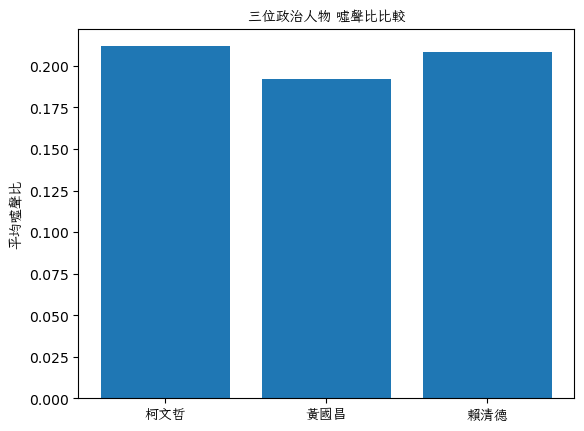

In [15]:
# 比較三個人的平均噓聲比
politicians = ["柯文哲", "黃國昌", "賴清德"]
avg_boo_ratio = [
    dfs["柯文哲"]["噓聲比"].mean(),
    dfs["黃國昌"]["噓聲比"].mean(),
    dfs["賴清德"]["噓聲比"].mean()
]

plt.bar(politicians, avg_boo_ratio)
plt.ylabel("平均噓聲比", fontproperties=font)
plt.title("三位政治人物 噓聲比比較", fontproperties=font)
plt.xticks(fontproperties=font)
plt.show()

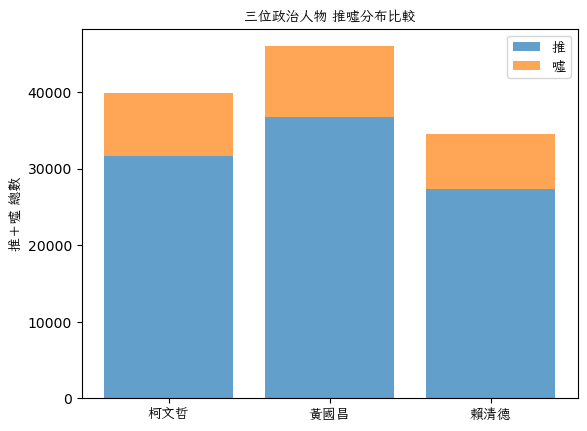

In [16]:
# 比較推文＋噓文總數
total_push = [
    dfs["柯文哲"]["push"].sum(),
    dfs["黃國昌"]["push"].sum(),
    dfs["賴清德"]["push"].sum()
]

total_boo = [
    dfs["柯文哲"]["boo"].sum(),
    dfs["黃國昌"]["boo"].sum(),
    dfs["賴清德"]["boo"].sum()
]

plt.bar(politicians, total_push, label='推', alpha=0.7)
plt.bar(politicians, total_boo, bottom=total_push, label='噓', alpha=0.7)
plt.ylabel("推＋噓 總數", fontproperties=font)
plt.title("三位政治人物 推噓分布比較", fontproperties=font)
plt.xticks(fontproperties=font)
plt.legend(prop=font)   # 圖例也換中文字型
plt.show()

In [8]:
!pip install jieba

In [9]:
!pip install wordcloud

## jieba 斷詞＋停用詞過濾

In [10]:
import jieba
import re

# 手動加入政治人物的姓名
custom_words = ["柯文哲", "黃國昌", "賴清德", "民進黨", "國民黨", "民眾黨", "蔡英文"]
for w in custom_words:
    jieba.add_word(w)

custom_stop = set("""
的 是 在 我 他 她 你 了 和 也 就 都 被 很 及 但 不 於 之 啦 啊 喔 呢 吧
佛 佛教 釋迦牟尼佛 阿彌陀佛 藥師佛 菩薩 大乘 小乘 上座部
阿羅漢 辟支佛 獨覺佛 涅槃 佛陀 佛弟子 僧寶 佛法僧 三寶
喬達摩 悉達多 摩耶 薩都丹拿 瞿曇彌 那先尊者 馬哈希
經 經典 經書 法華經 心經 金剛經 華嚴經 般涅槃經 楞伽經
帝釋所問經 彌蘭王問經 支佛 聲聞 諸佛 十方 之言 眾生 釋迦 牟尼佛 佛是 獨覺 弟子 妙法 蓮華經
極樂 因為 這個 這樣 表示 真的 如果 可以 不是 什麼 還是 我們 就是 現在 這些 知道 是不是
所以 今天 實不應 如是 怎麼 還有 乃至 已經 但是 還有 彼是 結果 自己 一個 不要 應該
出世 解脫 大王 地藏王 作者 世界 所有 瞎掰 真正 成佛 覺者 一剎 大家 可能 不會 沒有
這種 繼續 只有 其他 繼續 例如 觀世音 他們 尊者 一切 菩薩觀 世音
""".split())

stopwords = set()
stopwords = stopwords.union(custom_stop)

def jieba_cut(s):
    if pd.isna(s):
        return []
    words = jieba.lcut(s)
    return [w for w in words if w not in stopwords and len(w) > 1]

# 對三位政治人物全部建立 tokens_no_stop
for name in dfs:
    dfs[name]["tokens_no_stop"] = dfs[name]["內文_clean"].apply(jieba_cut)

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\b7869\AppData\Local\Temp\jieba.cache
Loading model cost 0.631 seconds.
Prefix dict has been built successfully.


## 文字雲 Word Cloud

文字雲：柯文哲


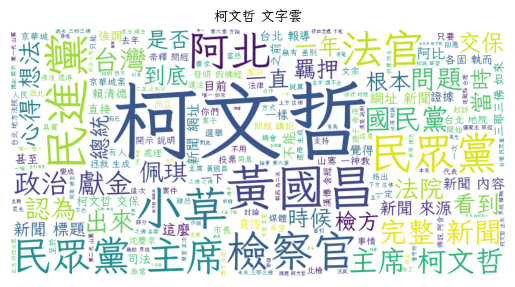

文字雲：黃國昌


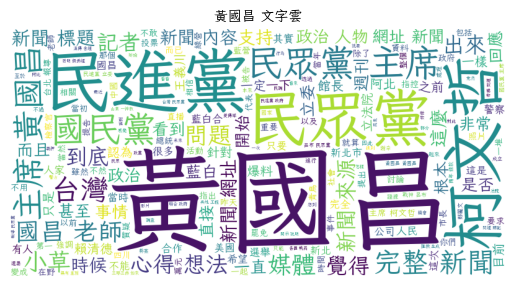

文字雲：賴清德


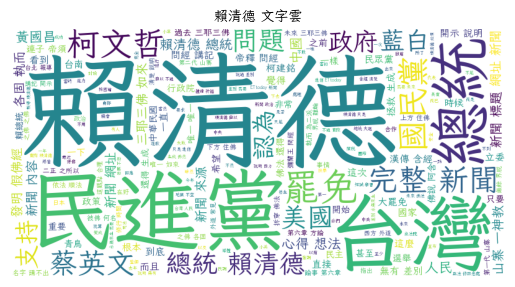

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for name in dfs:
    print(f"文字雲：{name}")

    all_words = []
    for tokens in dfs[name]["tokens_no_stop"]:
        all_words.extend(tokens)

    text = " ".join(all_words)

    wc = WordCloud(font_path=font_path, width=800, height=400, background_color="white")
    plt.imshow(wc.generate(text))
    plt.axis("off")
    plt.title(f"{name} 文字雲", fontproperties=font)
    plt.show()

## 關鍵詞比較（Keyword Comparison）

In [14]:
# 做詞頻（Term Frequency, TF）

from collections import Counter

word_counts = {}

for name in dfs:
    all_words = sum(dfs[name]["tokens_no_stop"], [])
    word_counts[name] = Counter(all_words)

In [15]:
# 每個政治人物的 Top 20 關鍵詞條列

for name in word_counts:
    print(f"\n=== {name} Top 20 詞 ===")
    print(word_counts[name].most_common(20))


=== 柯文哲 Top 20 詞 ===
[('柯文哲', 10142), ('民眾黨', 2073), ('政治', 1635), ('新聞', 1325), ('黃國昌', 1209), ('交保', 1174), ('賴清德', 1164), ('檢察官', 1150), ('主席', 1144), ('羈押', 1117), ('民進黨', 1072), ('小草', 1025), ('台北', 987), ('台灣', 973), ('司法', 930), ('被告', 924), ('出來', 875), ('法官', 841), ('阿北', 776), ('唯一', 760)]

=== 黃國昌 Top 20 詞 ===
[('黃國昌', 9336), ('民眾黨', 2669), ('主席', 1812), ('柯文哲', 1663), ('新聞', 1658), ('民進黨', 1642), ('國民黨', 1275), ('記者', 1246), ('政治', 1124), ('立委', 1034), ('台灣', 983), ('賴清德', 962), ('媒體', 939), ('報導', 705), ('國昌', 689), ('老師', 592), ('問題', 578), ('完整', 574), ('政府', 545), ('出來', 539)]

=== 賴清德 Top 20 詞 ===
[('賴清德', 8398), ('民進黨', 2575), ('總統', 2467), ('台灣', 2429), ('新聞', 1542), ('罷免', 1181), ('唯一', 1017), ('國民黨', 940), ('柯文哲', 877), ('政治', 816), ('說明', 810), ('蔡英文', 779), ('政府', 756), ('佛法', 751), ('問題', 713), ('主席', 713), ('支持', 710), ('名字', 685), ('人民', 685), ('美國', 663)]


In [16]:
# 尋找「獨特詞 Unique Words」，反映議題差異

def unique_words(target, others, top=20):
    target_words = set(word_counts[target])
    other_words = set()
    for o in others:
        other_words |= set(word_counts[o])
    diff = target_words - other_words
    # 排序：把最常出現的排前面
    sorted_words = sorted(diff, key=lambda x: word_counts[target][x], reverse=True)
    return sorted_words[:top]

print("柯文哲 獨特詞：", unique_words("柯文哲", ["黃國昌", "賴清德"]))
print("黃國昌 獨特詞：", unique_words("黃國昌", ["柯文哲", "賴清德"]))
print("賴清德 獨特詞：", unique_words("賴清德", ["柯文哲", "黃國昌"]))

柯文哲 獨特詞： ['邱清章', '李文娟', 'HPV', '周芳', 'USB', '地板', '陳俊源', '林欽榮', '選舉權', '公展', '楊智盛', '告警', '就醫', '侵占罪', '決行', '張靜', '戴利玲', '蔡明興', '提訊', '牢房']
黃國昌 獨特詞： ['張晉源', '李光昕', '世軒', '依依', '張凱維', '台鋼', '央廣', '燒不起', '李郁', '個資', '地質', '榮泉', '侯漢廷', '小姨子', '股權', '建平', '黑名', '柯晨', '供售', '鏡傳媒']
賴清德 獨特詞： ['安倍', '晉三', '巴拉圭', '演習', '十講', '友邦', '終戰', '二戰', '結十講', '老綠', '書店', '台日', '得主', '不孝子', '境美國', '同盟', '罷區', '不進', '台肥', '壽司']


In [17]:
# 交集詞（共同熱門議題）

common_words = (
    set(word_counts["柯文哲"]) &
    set(word_counts["黃國昌"]) &
    set(word_counts["賴清德"])
)

common_top = sorted(
    list(common_words),
    key=lambda x: word_counts["柯文哲"][x] + word_counts["黃國昌"][x] + word_counts["賴清德"][x],
    reverse=True
)[:20]

print("三人人共同詞 Top 20：", common_top)

三人人共同詞 Top 20： ['柯文哲', '黃國昌', '賴清德', '民進黨', '民眾黨', '新聞', '台灣', '主席', '總統', '政治', '國民黨', '記者', '唯一', '出來', '問題', '立委', '說明', '只是', '台北', '小草']


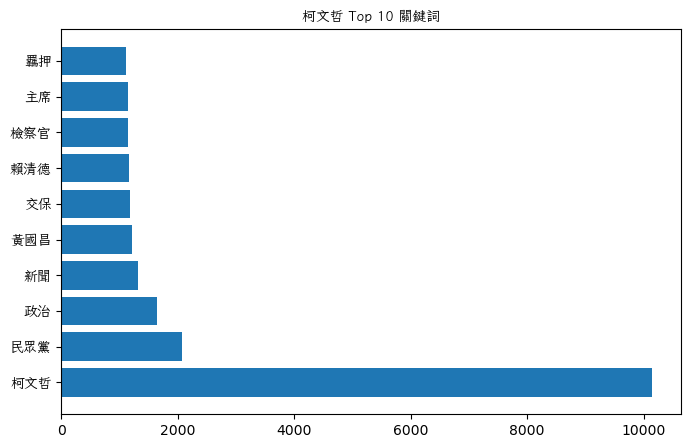

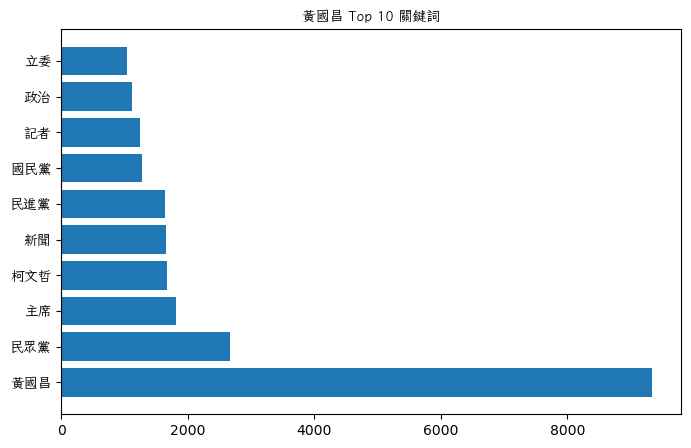

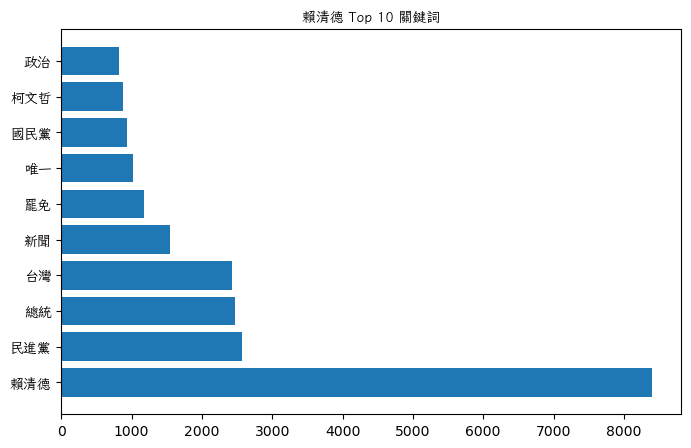

In [18]:
# 比較圖

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname=font_path)

def plot_top_words(counts, person, n=10):
    words, freqs = zip(*counts.most_common(n))
    plt.figure(figsize=(8,5))
    plt.barh(words, freqs)
    plt.title(f"{person} Top {n} 關鍵詞", fontproperties=font)
    plt.yticks(fontproperties=font)
    plt.show()

plot_top_words(word_counts["柯文哲"], "柯文哲")
plot_top_words(word_counts["黃國昌"], "黃國昌")
plot_top_words(word_counts["賴清德"], "賴清德")

## 每日走勢比較圖

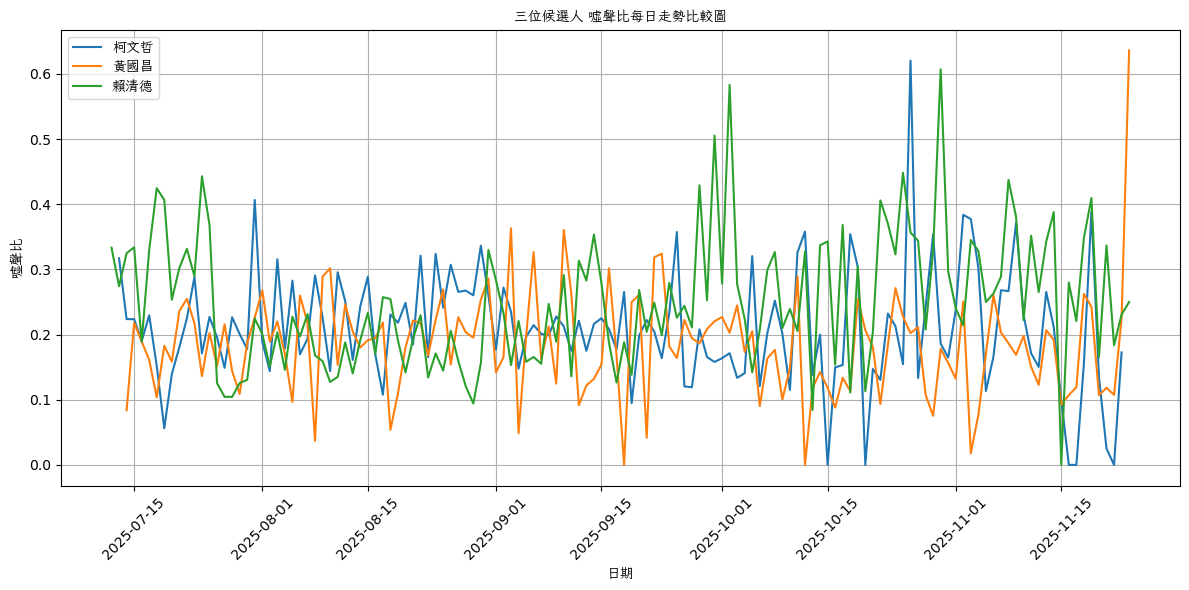

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, df in dfs.items():
    # 日期欄位名稱若是 "時間"、"date"、"datetime" 要自己改
    df['時間'] = pd.to_datetime(df['時間'], errors='coerce')

    # 有些會有空白行、壞格式 → 去掉 NaT 行
    df = df.dropna(subset=['時間'])
    
    # 若每天有多筆，做每日平均
    daily = df.groupby(df['時間'].dt.date)['噓聲比'].mean()

    # 畫圖
    plt.plot(daily.index, daily.values, label=name)

plt.xlabel("日期", fontproperties=font)
plt.ylabel("噓聲比", fontproperties=font)
plt.title("三位候選人 噓聲比每日走勢比較圖", fontproperties=font)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(prop=font)
plt.tight_layout()
plt.show()

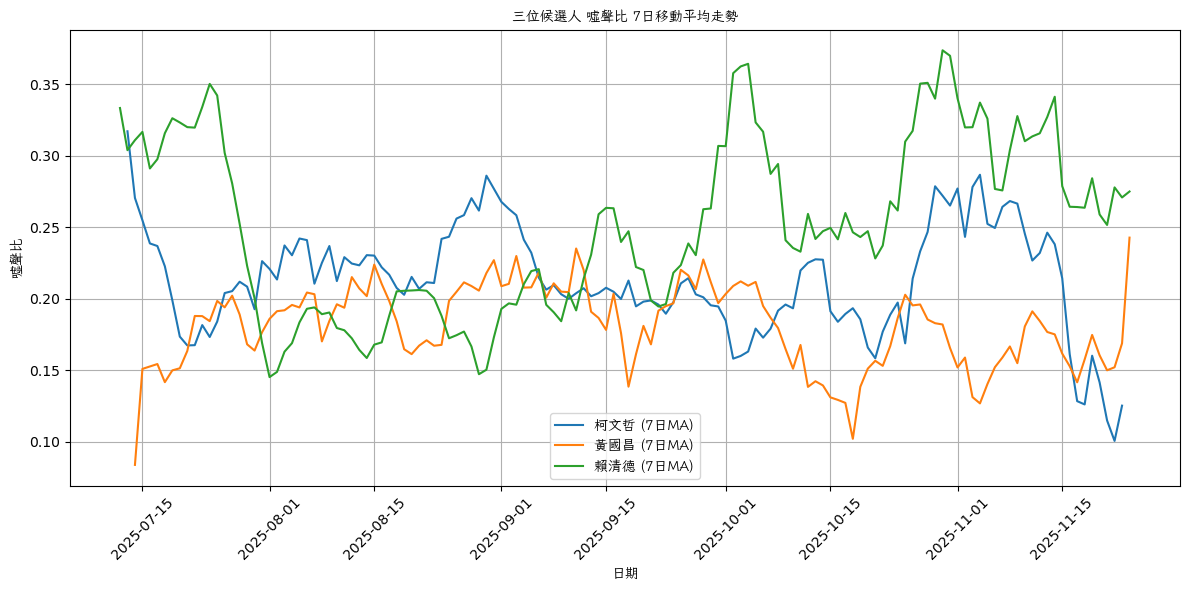

In [20]:
# 加入 7 日移動平均（更平滑）

plt.figure(figsize=(12, 6))

for name, df in dfs.items():
    df['時間'] = pd.to_datetime(df['時間'], errors='coerce')
    df = df.dropna(subset=['時間'])
    daily = df.groupby(df['時間'].dt.date)['噓聲比'].mean()
    
    ma7 = daily.rolling(7, min_periods=1).mean()
    plt.plot(ma7.index, ma7.values, label=f"{name} (7日MA)")

plt.xlabel("日期", fontproperties=font)
plt.ylabel("噓聲比", fontproperties=font)
plt.title("三位候選人 噓聲比 7日移動平均走勢", fontproperties=font)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(prop=font)
plt.tight_layout()
plt.show()